In [8]:
from typing import List, TypedDict
import time

from langchain_community.document_loaders import PyPDFLoader
from langchain_community.vectorstores import FAISS
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv

load_dotenv()

True

In [9]:

docs = (
    PyPDFLoader(r"C:\Users\amito\PycharmProjects\langraph_scripts\CRAG\2.Designing Machine Learning Systems An Iterative Process for Production-Ready (Chip Huyen).pdf").load() +
    PyPDFLoader(r"C:\Users\amito\PycharmProjects\langraph_scripts\CRAG\Storytelling-with-Data_-A-Data-Visualization-Guide-for-Busine....pdf").load()
)

In [10]:
len(docs)

673

In [11]:
# 2) Chunk
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

# 3) Clean text to avoid UnicodeEncodeError (surrogates from PDF extraction)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

In [12]:
len(chunks)

1836

In [13]:
# 3) Index (fresh collection each run)
embeddings = OpenAIEmbeddings(model='text-embedding-3-large')
vector_store = FAISS.from_documents(chunks, embeddings)

In [14]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})


In [15]:

# 4) LLM + prompt
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [22]:
class State(TypedDict):
    question: str
    docs: List[Document]
    answer: str

    strips : List[str]
    kept_strips : List[str]
    refined_context : str


In [17]:
def retrieve(state):
    q = state["question"]
    return {"docs": retriever.invoke(q)}

In [18]:
prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "Answer only from the context. If not in context, say you don't know."),
        ("human", "Question: {question}\n\nContext:\n{context}"),
    ]
)
def generate(state):
    context = "\n\n".join(d.page_content for d in state["docs"])
    out = (prompt | llm).invoke({"question": state["question"], "context": context})
    return {"answer": out.content}

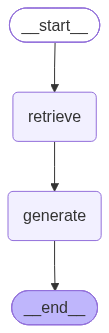

In [19]:
g = StateGraph(State)
g.add_node("retrieve", retrieve)
g.add_node("generate", generate)
g.add_edge(START, "retrieve")
g.add_edge("retrieve", "generate")
g.add_edge("generate", END)
app = g.compile()

app

In [20]:
# 5) Run
res = app.invoke({"question": "WHat is a transformer in deep learning.", "docs": [], "answer": ""})
print(res["answer"])

A transformer in deep learning is a model architecture that has largely replaced previous architectures for natural language processing (NLP) tasks. It is known for its ability to handle sequences of data and has been influential in the development of models like BERT.


In [21]:

print(res['docs'][0].page_content)
print('*'*100)
print(res['docs'][1].page_content)
print('*'*100)
print(res['docs'][2].page_content)
print('*'*100)
print(res['docs'][3].page_content)

a transformer. Hardware vendors like NVIDIA and Google focus on optimizing
popular models like ResNet-50 and BERT for their hardware. But what if you, as an
ML researcher, come up with a new model architecture? Y ou might need to optimize
it yourself to show that it’s fast first before it’s adopted and optimized by hardware
vendors.
If you don’t have ideas for good heuristics, one possible solution might be to try
all possible ways to execute a computation graph, record the time they need to run,
then pick the best one. However, given a combinatorial number of possible paths,
exploring them all would be intractable. Luckily, approximating the solutions to
intractable problems is what ML is good at. What if we use ML to narrow down the
search space so we don’t have to explore that many paths, and predict how long a
****************************************************************************************************
may also be trained at the same time. 23 One example of a distilled netwo